In [14]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pickle import load

import re
from tqdm import tqdm

import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    # Use LaTeX
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Lines
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 1,

    # Ticks
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Save figures
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [15]:
DATA_PATH = 'data/'
FILE_NAME = 'charge_stability.pkl'
LOG_FILE = 'charge_stability.log'

log = open(DATA_PATH + LOG_FILE, 'r').readlines()
charge_stability = load(open(DATA_PATH + FILE_NAME, 'rb'))

In [16]:
Vs = np.linspace(0, 1, 100)

list(charge_stability['charge_stability'].items())[-1]

((37, 7), (2, -45.17011566720758))

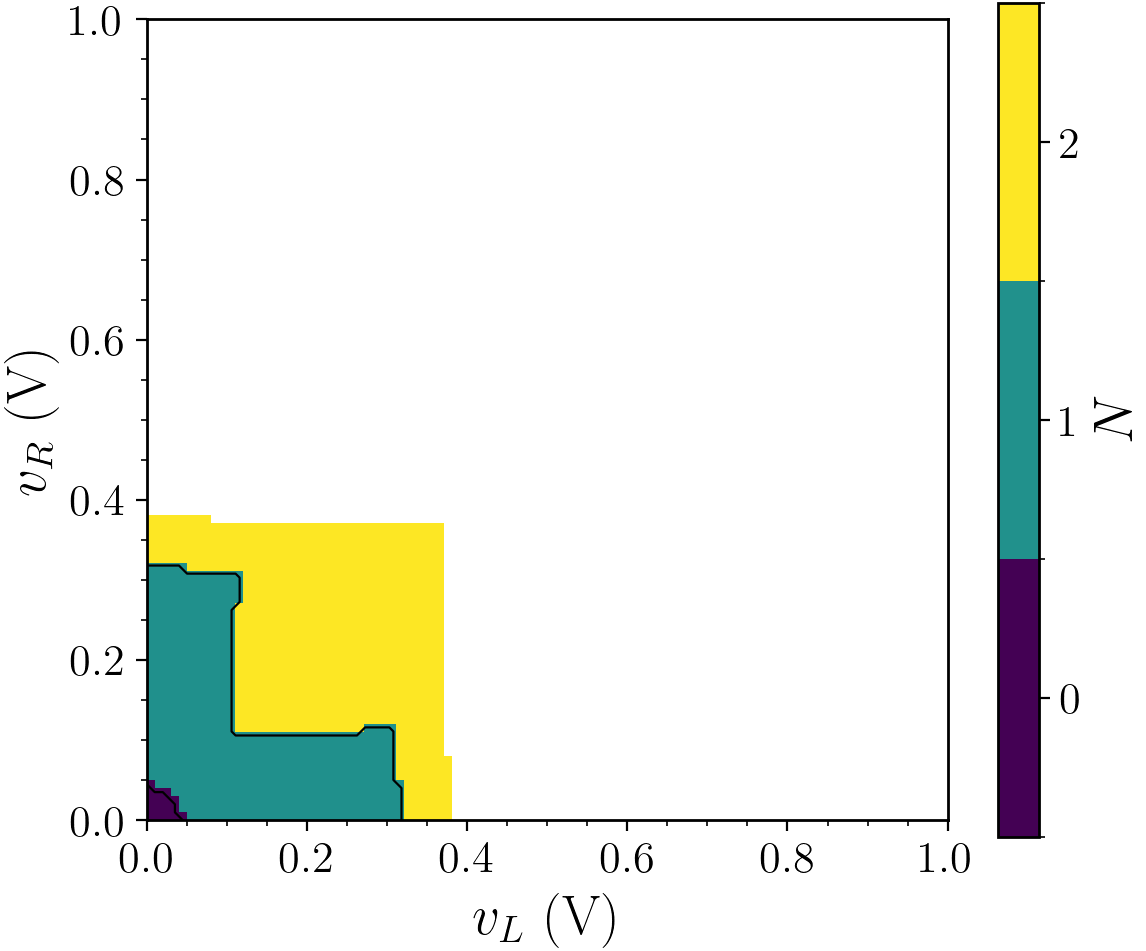

In [17]:
cs = charge_stability['charge_stability']

n_grid = np.full((len(Vs), len(Vs)), np.nan)
energy_grid = np.full((len(Vs), len(Vs)), np.nan)

for (i, j), (n, en) in cs.items():
    n_grid[j, i] = n
    energy_grid[j, i] = en

    # Mirror the skipped half using left-right symmetry.
    if i != j:
        n_grid[i, j] = n
        energy_grid[i, j] = en

valid_n = n_grid[~np.isnan(n_grid)].astype(int)
if valid_n.size == 0:
    raise ValueError('No charge-stability points found.')

n_min = valid_n.min()
n_max = valid_n.max()

cmap = plt.get_cmap('viridis', n_max - n_min + 1).copy()
cmap.set_bad('white')
bounds = np.arange(n_min - 0.5, n_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=200)
im = ax.imshow(
    np.ma.masked_invalid(n_grid),
    origin='lower',
    extent=[Vs[0], Vs[-1], Vs[0], Vs[-1]],
    cmap=cmap,
    norm=mpl.colors.BoundaryNorm(bounds, cmap.N),
    interpolation='nearest',
    aspect='equal',
)

if n_max > n_min:
    ax.contour(
        Vs,
        Vs,
        n_grid,
        levels=np.arange(n_min + 0.5, n_max + 0.5, 1),
        colors='k',
        linewidths=0.8,
    )

cbar = fig.colorbar(im, ax=ax, ticks=np.arange(n_min, n_max + 1))
cbar.set_label(r'$N$')

ax.set_xlabel(r'$v_L$ (V)')
ax.set_ylabel(r'$v_R$ (V)')
#ax.set_xlim(Vs[0], Vs[-1])
#ax.set_ylim(Vs[0], Vs[-1])
current_V_max = Vs[np.max(np.where(~np.isnan(n_grid)))]
#ax.set_xlim(Vs[0], current_V_max)
#ax.set_ylim(Vs[0], current_V_max)

fig.tight_layout()
plt.show()

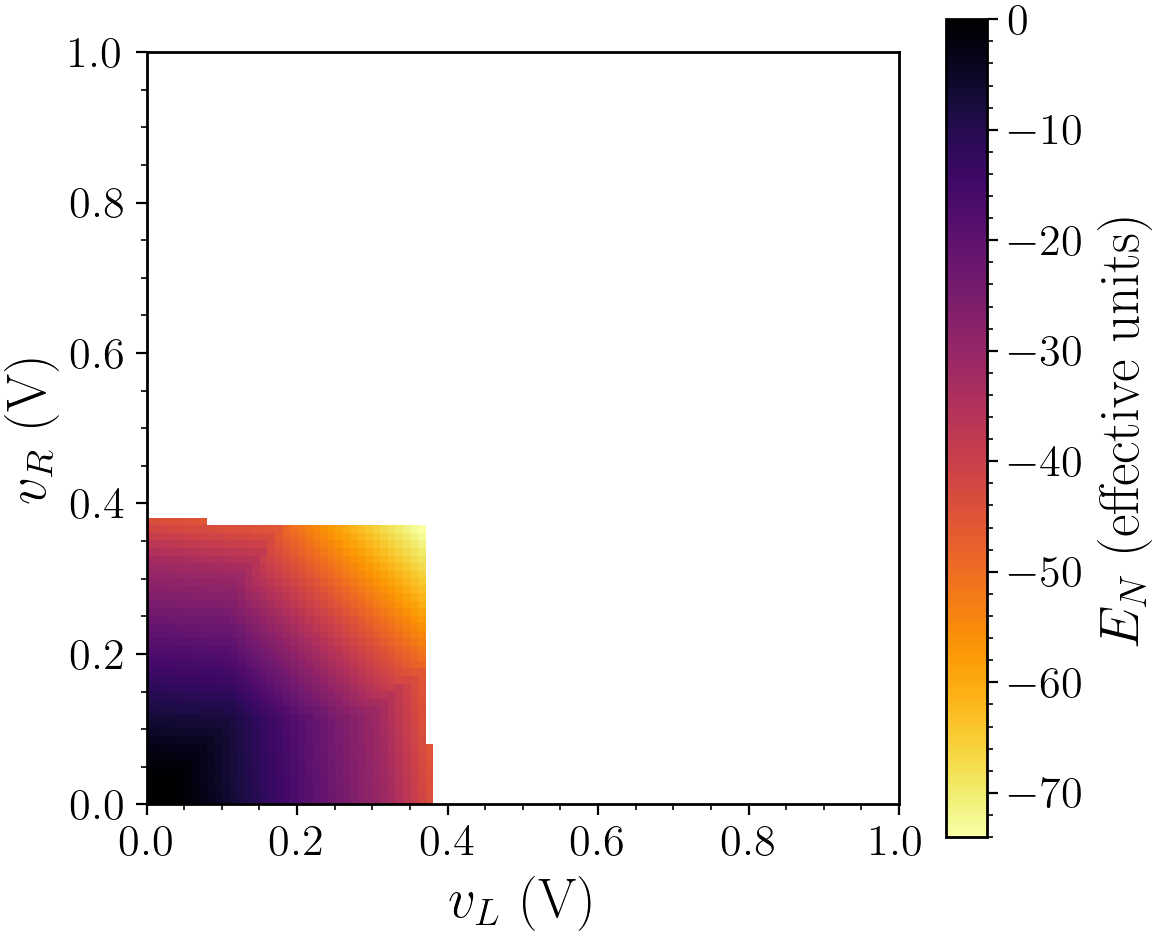

In [18]:
cs = charge_stability['charge_stability']

energy_grid = np.full((len(Vs), len(Vs)), np.nan)

for (i, j), (n, en) in cs.items():
    energy_grid[j, i] = en

    # Mirror the skipped half using left-right symmetry.
    if i != j:
        energy_grid[i, j] = en

valid_j, valid_i = np.where(~np.isnan(energy_grid))
if valid_i.size == 0:
    raise ValueError('No energy points found.')

current_V_max = Vs[max(valid_i.max(), valid_j.max())]

cmap = plt.get_cmap('inferno_r').copy()
cmap.set_bad('white')

fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=200)
im = ax.imshow(
    np.ma.masked_invalid(energy_grid),
    origin='lower',
    extent=[Vs[0], Vs[-1], Vs[0], Vs[-1]],
    cmap=cmap,
    interpolation='nearest',
    aspect='equal',
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$E_N$ (effective units)')

ax.set_xlabel(r'$v_L$ (V)')
ax.set_ylabel(r'$v_R$ (V)')
#ax.set_xlim(Vs[0], current_V_max)
#ax.set_ylim(Vs[0], current_V_max)

fig.tight_layout()
plt.show()